### Contributions
Clarisa - Data cleaning, Task 1, Task 2

Jacob - Task 3 & Analysis

Ava - Task 4 & Analysis 

Ethan - Supervised, task 1 task 2 anaylsis, Unsupervised task analysis Question's 1 and 2 

Ryan - Supervised task revision, Unsupervised task visuals and analysis, project compilement and version management

David - Unsupervised task visual, question 3 analysis

# Phase 1 Creating a Corpus
### Imports

In [81]:
#pip install pandas numpy scikit-learn matplotlib seaborn scipy nltk sentence-transformers

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import sentence_transformers as sbert

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram

nltk.download("vader_lexicon")
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import MinMaxScaler

RANDOM_STATE = 42

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/davidhuang/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### Data Cleaning

In [82]:
rawcorpus_df = pd.read_csv("AllCorpus.csv")
print(f"Raw corpus: {len(rawcorpus_df)} documents")
rawcorpus_df.head()

Raw corpus: 650 documents


,doc_id,text,category_1,category_2,sentiment
0,1,Trump's presidency has been tattered with scan...,1,none,Negative
1,2,My machine learning course has been really enj...,2,none,Positive
2,3,The plot of the final season of The Boys has b...,3,none,Negative
3,4,I enjoy getting learning about strength traini...,4,none,Positive
4,5,It's concerning our government is partnering w...,1,2,Negative


In [83]:
df = rawcorpus_df.copy()

# --- Normalize sentiment ---
df["sentiment"] = df["sentiment"].str.strip().str.capitalize()
typo_map = {
    "Nuetral":  "Neutral",
    "Neutral.": "Neutral",
    "Positve":  "Positive",
    "Postive":  "Positive",
}
df["sentiment"] = df["sentiment"].replace(typo_map)

# --- Normalize category_2 ---
df["category_2"] = df["category_2"].astype(str).str.strip().str.lower()
df["category_2"] = df["category_2"].replace({"none": np.nan, "nan": np.nan})

# --- Drop invalid rows ---
# category_1 = -1 are placeholder rows; also drop rows missing sentiment
df = df[df["category_1"] != -1]
df = df[df["sentiment"].notna()]
df = df[df["text"].notna()]
df = df.reset_index(drop=True)

# --- Helper column ---
df["is_mixed"] = df["category_2"].notna()

print(f"Clean corpus: {len(df)} documents")
print(f"  Mixed-category docs : {df['is_mixed'].sum()}")
print(f"  Single-category docs: {(~df['is_mixed']).sum()}")
print()
print("Sentiment distribution:")
print(df["sentiment"].value_counts())
print()
print("Primary category distribution:")
print(df["category_1"].value_counts().sort_index())

Clean corpus: 639 documents
  Mixed-category docs : 319
  Single-category docs: 320

Sentiment distribution:
sentiment
Positive    230
Negative    211
Neutral     198
Name: count, dtype: int64

Primary category distribution:
category_1
1    168
2    140
3    129
4    117
5     85
Name: count, dtype: int64


In [84]:
category_names = {
    1: "News/Politics",
    2: "CS/Data Science",
    3: "Lit/Music/TV",
    4: "Health/Activity",
    5: "Food/Home/Pets",
}
df["category_label"] = df["category_1"].map(category_names)
df[["doc_id", "text", "category_1", "category_label", "sentiment", "is_mixed"]].head(8)

,doc_id,text,category_1,category_label,sentiment,is_mixed
0,1,Trump's presidency has been tattered with scan...,1,News/Politics,Negative,False
1,2,My machine learning course has been really enj...,2,CS/Data Science,Positive,False
2,3,The plot of the final season of The Boys has b...,3,Lit/Music/TV,Negative,False
3,4,I enjoy getting learning about strength traini...,4,Health/Activity,Positive,False
4,5,It's concerning our government is partnering w...,1,News/Politics,Negative,True
5,6,Modern workout apps are excellent in how they ...,2,CS/Data Science,Positive,True
6,7,Democrats will elect a strong candidate in 202...,1,News/Politics,Positive,False
7,8,Viewing a series for entertainment depends on ...,2,CS/Data Science,Neutral,True


### Vectorization

In [85]:
bow_vectorizer    = CountVectorizer(stop_words="english")
binary_vectorizer = CountVectorizer(stop_words="english", binary=True)
tfidf_vectorizer  = TfidfVectorizer(stop_words="english")

X_bow    = bow_vectorizer.fit_transform(df["text"])
X_binary = binary_vectorizer.fit_transform(df["text"])
X_tfidf  = tfidf_vectorizer.fit_transform(df["text"])

print(f"Vocabulary size : {len(bow_vectorizer.vocabulary_)} terms")
print(f"BoW matrix shape: {X_bow.shape}")

# Preview the first 5 documents x first 12 vocabulary terms for each representation
bow_df    = pd.DataFrame(X_bow.toarray(),    columns=bow_vectorizer.get_feature_names_out())
binary_df = pd.DataFrame(X_binary.toarray(), columns=binary_vectorizer.get_feature_names_out())
tfidf_df  = pd.DataFrame(np.round(X_tfidf.toarray(), 3), columns=tfidf_vectorizer.get_feature_names_out())

print("Bag-of-Words (first 5 docs x 12 terms):")
display(bow_df.iloc[:5, :12])

print("\nBinary Presence (first 5 docs x 12 terms):")
display(binary_df.iloc[:5, :12])

print("\nTF-IDF (first 5 docs x 12 terms):")
display(tfidf_df.iloc[:5, :12])

Vocabulary size : 2970 terms
BoW matrix shape: (639, 2970)
Bag-of-Words (first 5 docs x 12 terms):


,10,100,111,12,20,2026,2028,30,5k,74,80,87
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0



Binary Presence (first 5 docs x 12 terms):


,10,100,111,12,20,2026,2028,30,5k,74,80,87
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0



TF-IDF (first 5 docs x 12 terms):


,10,100,111,12,20,2026,2028,30,5k,74,80,87
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Cosine Similarity Check

In [86]:
def show_similar_documents(X, vectorizer_name, query_index=0, top_n=3):
    sims = cosine_similarity(X[query_index], X).ravel()
    neighbours = np.argsort(sims)[::-1][1:top_n + 1]
    print(f"Query [{query_index}]: {df.loc[query_index, 'text'][:80]}...")
    print(f"Nearest documents using cosine similarity on {vectorizer_name}:")
    for nb in neighbours:
        print(f"  sim={sims[nb]:.3f} | doc {nb}: {df.loc[nb, 'text'][:80]}...")
    print()

# Query doc 105: "The artist Malcolm Todd generated a lot of social media buzz..."
show_similar_documents(X_bow,    "BoW",             query_index=105)
show_similar_documents(X_binary, "Binary Presence", query_index=105)
show_similar_documents(X_tfidf,  "TF-IDF",          query_index=105)

Query [105]: The artist Malcolm Todd generated a lot of social media buzz by playing a song f...
Nearest documents using cosine similarity on BoW:
  sim=0.229 | doc 82: The album got almost no attention at first, but the tracklist went viral through...
  sim=0.188 | doc 140: A recent review of the new Malcolm Todd album was highly positive because of his...
  sim=0.183 | doc 446: The author’s latest novel became a viral hit on social media....

Query [105]: The artist Malcolm Todd generated a lot of social media buzz by playing a song f...
Nearest documents using cosine similarity on Binary Presence:
  sim=0.188 | doc 82: The album got almost no attention at first, but the tracklist went viral through...
  sim=0.188 | doc 140: A recent review of the new Malcolm Todd album was highly positive because of his...
  sim=0.183 | doc 446: The author’s latest novel became a viral hit on social media....

Query [105]: The artist Malcolm Todd generated a lot of social media buzz by playing a son

As we can see from the various different cosine distance similarity measurements. The highest similarity achieved was through the BOW method. This is to be expected as BOW does not reduce the weight of common terms across all of the corpus meaning that there will be more shared articles, like “at” or “the”. Thus making a higher similarity score. All of these scores however are far from -1 or 1 so there is little similarity.

# Phase 2 Supervised Learning

In [87]:
def plot_confusion(y_true, y_pred, title):
    """Plot a labelled confusion-matrix heatmap."""
    labels = sorted(pd.Series(list(y_true) + list(y_pred)).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def evaluate_classifier(model, X, y, title, test_size=0.2):
    """
    Stratified train/test split, fit model, print metrics, show confusion matrix.
    Returns a summary dict for the results table.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("=" * 70)
    print(title)
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    plot_confusion(y_test, y_pred, title)

    return {"title": title, "accuracy": round(acc, 3)}


# Collect all results for the summary table
tasks = []

## Task 1 Logistic Regression

Task 1 — Category Classification | LR on BoW
Accuracy: 0.805
                 precision    recall  f1-score   support

CS/Data Science       0.77      0.86      0.81        28
 Food/Home/Pets       0.62      0.47      0.53        17
Health/Activity       0.76      0.83      0.79        23
   Lit/Music/TV       0.88      0.85      0.86        26
  News/Politics       0.88      0.88      0.88        34

       accuracy                           0.80       128
      macro avg       0.78      0.78      0.78       128
   weighted avg       0.80      0.80      0.80       128



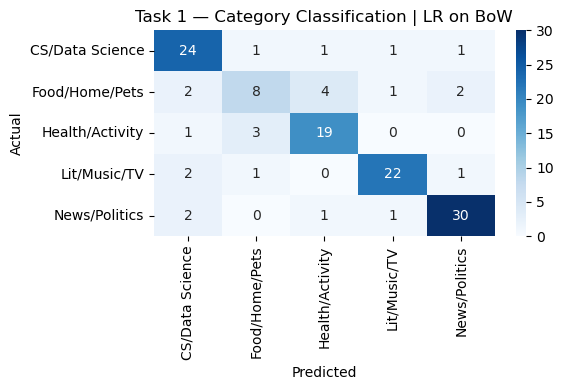

Task 1 — Category Classification | LR on TF-IDF
Accuracy: 0.773
                 precision    recall  f1-score   support

CS/Data Science       0.73      0.79      0.76        28
 Food/Home/Pets       0.71      0.29      0.42        17
Health/Activity       0.77      0.87      0.82        23
   Lit/Music/TV       0.84      0.81      0.82        26
  News/Politics       0.78      0.91      0.84        34

       accuracy                           0.77       128
      macro avg       0.77      0.73      0.73       128
   weighted avg       0.77      0.77      0.76       128



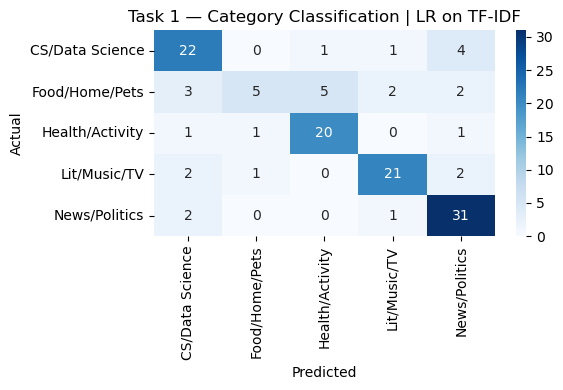

In [88]:
y_category = df["category_label"]

# Logistic Regression on BoW
tasks.append(evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_bow, y_category,
    "Task 1 — Category Classification | LR on BoW"
))

# Logistic Regression on TF-IDF
tasks.append(evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_tfidf, y_category,
    "Task 1 — Category Classification | LR on TF-IDF"
))

Our task one is performing Logistic regression upon the different vectorizing methods we used. We found the accuracy on the Bag of words to be higher on average. BOW obtained higher precision in all categories except Food/Home/Pets as well as Health and activity. Tf-IDF achieved higher recall on Health/Activity and Lit/Music/TV but lower on every other category. It should be noted that both methods achieved less than a .5 recall on the Food/Home/Pets. TF-IDF received lower F1 scores across all categories except Health/Activity. From this information we believe that our BOW is more effective for the purpose of our understanding. 

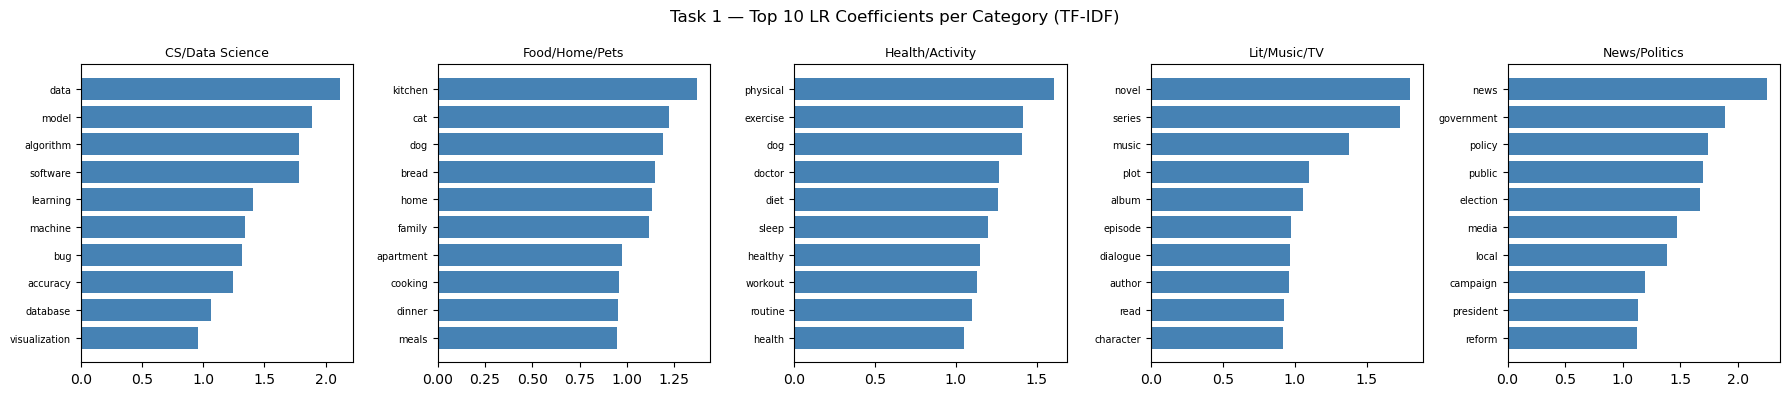

In [89]:
#visualizing yhr 10 most predictgive terms per category LR coff on tf-idf
lr_cat = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_cat.fit(X_tfidf, y_category)

feature_names = tfidf_vectorizer.get_feature_names_out()
fig, axes = plt.subplots(1, len(lr_cat.classes_), figsize=(18, 4), sharey=False)

for ax, cls_name, coefs in zip(axes, lr_cat.classes_, lr_cat.coef_):
    top_idx = np.argsort(coefs)[-10:]
    ax.barh(feature_names[top_idx], coefs[top_idx], color="steelblue")
    ax.set_title(cls_name, fontsize=9)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Task 1 — Top 10 LR Coefficients per Category (TF-IDF)", fontsize=12)
plt.tight_layout()
plt.show()

These plots show the 10 words per category that have the highest frequency in their respective categories.

Task 1 — Sentiment Classification | LR on BoW
Accuracy: 0.773
              precision    recall  f1-score   support

    Negative       0.94      0.76      0.84        42
     Neutral       0.67      0.72      0.70        40
    Positive       0.75      0.83      0.78        46

    accuracy                           0.77       128
   macro avg       0.79      0.77      0.77       128
weighted avg       0.79      0.77      0.78       128



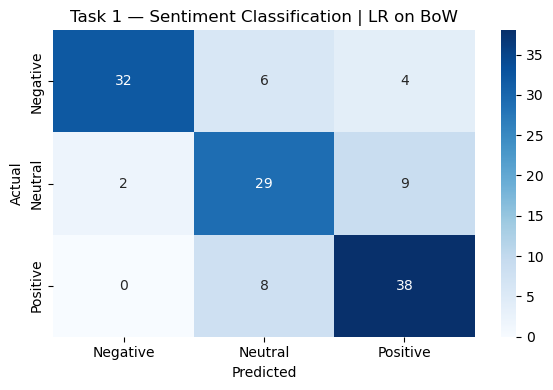

Task 1 — Sentiment Classification | LR on TF-IDF
Accuracy: 0.758
              precision    recall  f1-score   support

    Negative       0.89      0.81      0.85        42
     Neutral       0.69      0.62      0.66        40
    Positive       0.70      0.83      0.76        46

    accuracy                           0.76       128
   macro avg       0.76      0.75      0.76       128
weighted avg       0.76      0.76      0.76       128



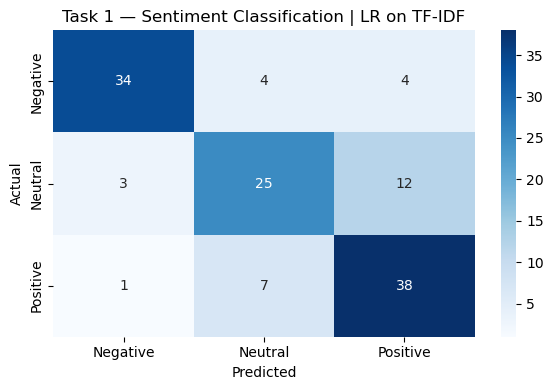

In [112]:
y_sentiment = df["sentiment"]

# Logistic Regression on BoW
tasks.append(evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_bow, y_sentiment,
    "Task 1 — Sentiment Classification | LR on BoW"
))

# Logistic Regression on TF-IDF
tasks.append(evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_tfidf, y_sentiment,
    "Task 1 — Sentiment Classification | LR on TF-IDF"
))

## Task 2 KNN Sentiment

Task 2 — Sentiment Classification | kNN (cosine) on BoW
Accuracy: 0.586
              precision    recall  f1-score   support

    Negative       0.62      0.74      0.67        42
     Neutral       0.50      0.38      0.43        40
    Positive       0.60      0.63      0.62        46

    accuracy                           0.59       128
   macro avg       0.57      0.58      0.57       128
weighted avg       0.58      0.59      0.58       128



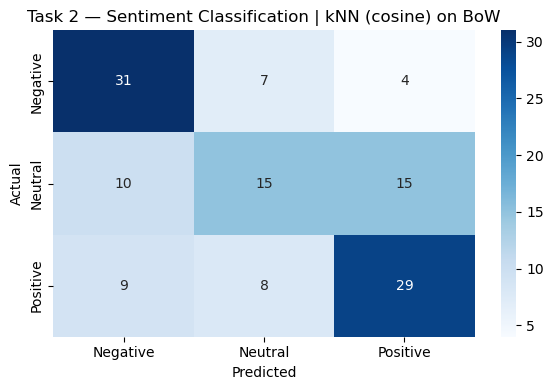

Task 2 — Sentiment Classification | kNN (cosine) on TF-IDF
Accuracy: 0.617
              precision    recall  f1-score   support

    Negative       0.60      0.83      0.70        42
     Neutral       0.63      0.47      0.54        40
    Positive       0.62      0.54      0.58        46

    accuracy                           0.62       128
   macro avg       0.62      0.62      0.61       128
weighted avg       0.62      0.62      0.61       128



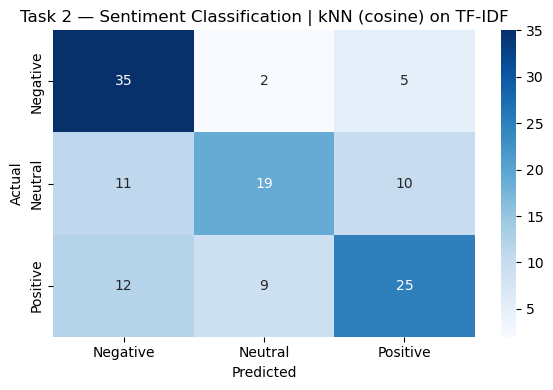

In [ ]:
# kNN with cosine similarity on BoW
tasks.append(evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    X_bow, y_sentiment,
    "Task 2 — Sentiment Classification | kNN (cosine) on BoW"
))

# kNN with cosine similarity on TF-IDF
tasks.append(evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    X_tfidf, y_sentiment,
    "Task 2 — Sentiment Classification | kNN (cosine) on TF-IDF"
))

Task 2 — Sentiment Classification | kNN (cosine) on Binary Presence
Accuracy: 0.625
              precision    recall  f1-score   support

    Negative       0.70      0.74      0.72        42
     Neutral       0.54      0.47      0.51        40
    Positive       0.61      0.65      0.63        46

    accuracy                           0.62       128
   macro avg       0.62      0.62      0.62       128
weighted avg       0.62      0.62      0.62       128



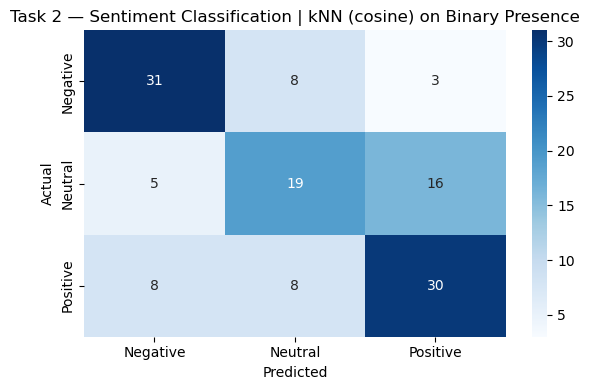

In [91]:
#cosine similarity vs biinary feature on KNN
tasks.append(evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    X_binary, y_sentiment,
    "Task 2 — Sentiment Classification | kNN (cosine) on Binary Presence"
))

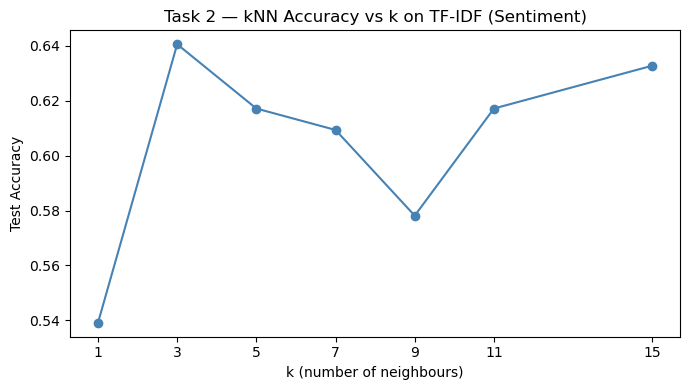

In [92]:
#finding the best k on tf-idf
X_tr, X_te, y_tr, y_te = train_test_split(
    X_tfidf, y_sentiment, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sentiment
)

k_values = [1, 3, 5, 7, 9, 11, 15]
k_accs   = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_tr, y_tr)
    k_accs.append(accuracy_score(y_te, knn.predict(X_te)))

plt.figure(figsize=(7, 4))
plt.plot(k_values, k_accs, marker="o", color="steelblue")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Test Accuracy")
plt.title("Task 2 — kNN Accuracy vs k on TF-IDF (Sentiment)")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

## Analysis: KNN Sentiment Classification
**BoW vs TF-IDF**

Knn benefits from TF-IDF because it reduces genereic words and emphasizes the unique vocab while logistic regression (LR) uses the raw word count in which the alhorithm assigns near-zero coefficients to irrelevamt or overly commonf eatures during trainign

**TF-IDF Cosine Similarity v.s. Binary Measures**

For classification of sentiment using KNN, we found Tf-IDF to have the highest accuracy. With Binary presence being a close runner up and BOW being last. This follows our intuition as we would hope that TF-IDF, a method of applying weights to words based upon their frequencies in all documents, would be able to apply weights properly to increase accuracy of sentiment. 

**LR vs KNN**

Our Logistic Regression outperformed our KNN models massively with about at 20% accuracy difference. I hypothesize that this is occurring due to the large amount of noisy data in the set heavily affecting KNN. Logistic regression is more resistant to the noisy data making it better suited for our purpose.

## Task 3 Naive Bayes Sentiment Classification

Task 3 — Sentiment Classification | NB on BoW
Accuracy: 0.703
              precision    recall  f1-score   support

    Negative       0.77      0.79      0.78        42
     Neutral       0.65      0.50      0.56        40
    Positive       0.69      0.80      0.74        46

    accuracy                           0.70       128
   macro avg       0.70      0.70      0.69       128
weighted avg       0.70      0.70      0.70       128



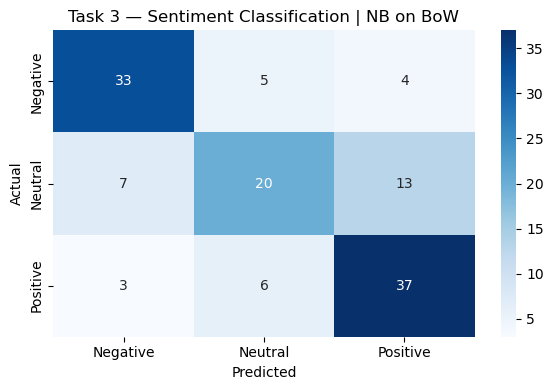

Task 3 — Sentiment Classification | NB on TF-IDF
Accuracy: 0.727
              precision    recall  f1-score   support

    Negative       0.85      0.83      0.84        42
     Neutral       0.75      0.38      0.50        40
    Positive       0.64      0.93      0.76        46

    accuracy                           0.73       128
   macro avg       0.75      0.71      0.70       128
weighted avg       0.75      0.73      0.71       128



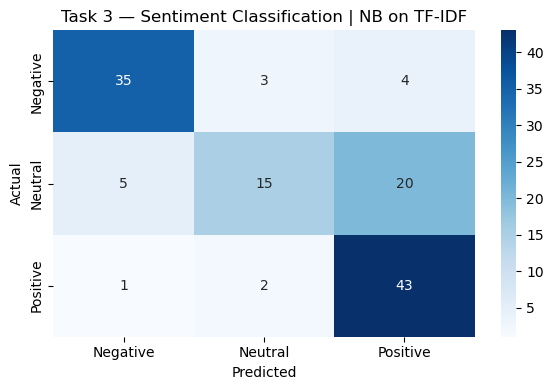

Task 3 — Sentiment Classification | NB on Binary Presence
Accuracy: 0.727
              precision    recall  f1-score   support

    Negative       0.79      0.81      0.80        42
     Neutral       0.69      0.50      0.58        40
    Positive       0.70      0.85      0.76        46

    accuracy                           0.73       128
   macro avg       0.73      0.72      0.71       128
weighted avg       0.73      0.73      0.72       128



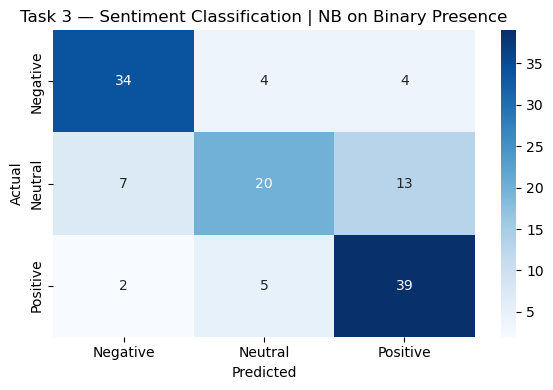

In [93]:
# NB on BoW
tasks.append(evaluate_classifier(
    MultinomialNB(),
    X_bow, y_sentiment,
    "Task 3 — Sentiment Classification | NB on BoW"
))

# NB on TF-IDF
tasks.append(evaluate_classifier(
    MultinomialNB(),
    X_tfidf, y_sentiment,
    "Task 3 — Sentiment Classification | NB on TF-IDF"
))

# NB on Binary Presence — cosine comparison
tasks.append(evaluate_classifier(
    MultinomialNB(),
    X_binary, y_sentiment,
    "Task 3 — Sentiment Classification | NB on Binary Presence"
))

## **Task 4 — Random Forest**

Task 4 — Category Classification | RF on BoW
Accuracy: 0.734
                 precision    recall  f1-score   support

CS/Data Science       0.73      0.79      0.76        28
 Food/Home/Pets       0.60      0.35      0.44        17
Health/Activity       0.81      0.91      0.86        23
   Lit/Music/TV       0.57      0.77      0.66        26
  News/Politics       0.93      0.74      0.82        34

       accuracy                           0.73       128
      macro avg       0.73      0.71      0.71       128
   weighted avg       0.75      0.73      0.73       128



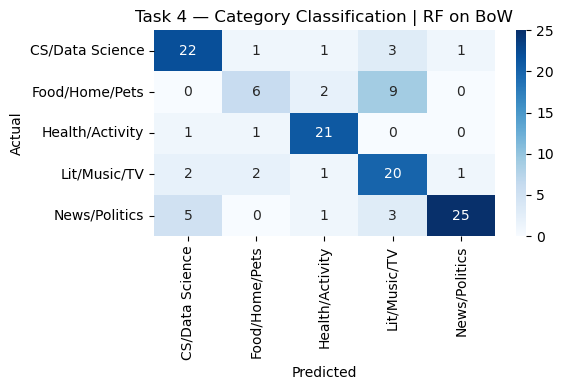

Task 4 — Category Classification | RF on TF-IDF
Accuracy: 0.742
                 precision    recall  f1-score   support

CS/Data Science       0.71      0.79      0.75        28
 Food/Home/Pets       0.60      0.35      0.44        17
Health/Activity       0.87      0.87      0.87        23
   Lit/Music/TV       0.59      0.85      0.70        26
  News/Politics       0.93      0.74      0.82        34

       accuracy                           0.74       128
      macro avg       0.74      0.72      0.72       128
   weighted avg       0.76      0.74      0.74       128



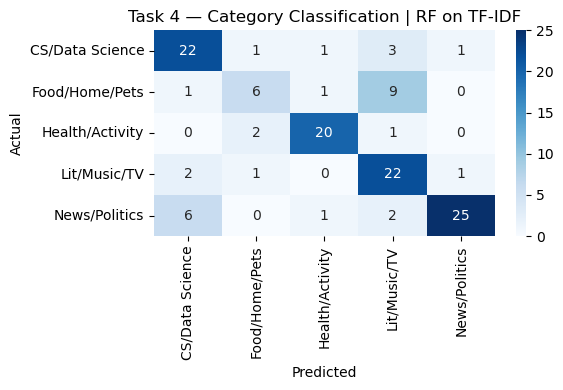

In [94]:
#I used Claude for drafting the code for random foresting
from sklearn.ensemble import RandomForestClassifier

# RF on BoW — category
tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_bow, y_category,
    "Task 4 — Category Classification | RF on BoW"
))

# RF on TF-IDF — category
tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_tfidf, y_category,
    "Task 4 — Category Classification | RF on TF-IDF"
))

**RF on TF-IDF vs RF on BoW showed little difference and the heatmap overall followed the same trend. Food/Home/Pets had the lowest classification accuracy compared to other categories.**

Task 4 — Sentiment Classification | RF on BoW
Accuracy: 0.789
              precision    recall  f1-score   support

    Negative       0.97      0.71      0.82        42
     Neutral       0.65      0.88      0.74        40
    Positive       0.84      0.78      0.81        46

    accuracy                           0.79       128
   macro avg       0.82      0.79      0.79       128
weighted avg       0.82      0.79      0.79       128



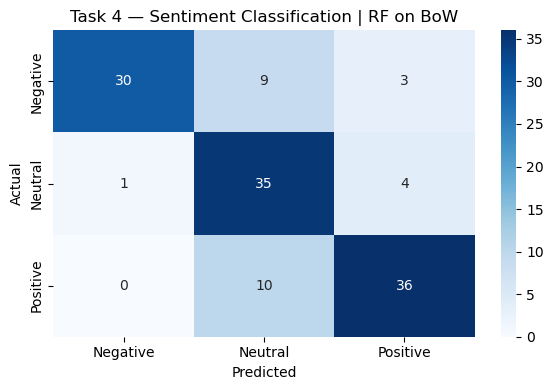

Task 4 — Sentiment Classification | RF on TF-IDF
Accuracy: 0.773
              precision    recall  f1-score   support

    Negative       0.97      0.69      0.81        42
     Neutral       0.60      0.88      0.71        40
    Positive       0.88      0.76      0.81        46

    accuracy                           0.77       128
   macro avg       0.82      0.78      0.78       128
weighted avg       0.82      0.77      0.78       128



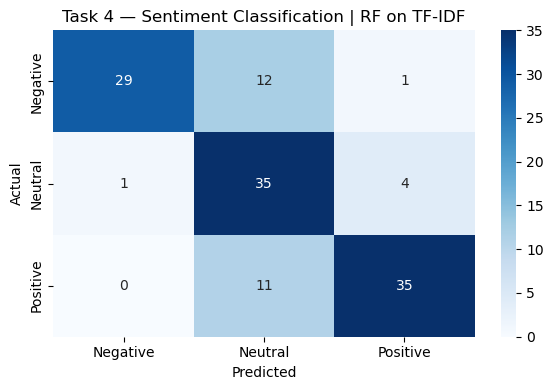

In [95]:
# RF on BoW — sentiment
tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_bow, y_sentiment,
    "Task 4 — Sentiment Classification | RF on BoW"
))

# RF on TF-IDF — sentiment
tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_tfidf, y_sentiment,
    "Task 4 — Sentiment Classification | RF on TF-IDF"
))

**For both BoW and TF-IDF the accuracy of sentiment classification overall followed the same trend.**

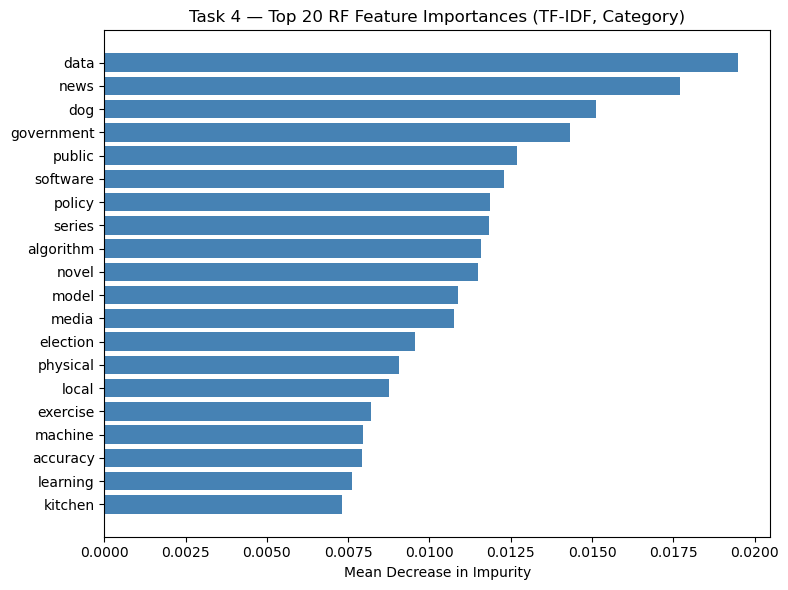

In [96]:
# Feature importances from a full-corpus RF (TF-IDF, category)
rf_cat = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_cat.fit(X_tfidf, y_category)

feature_names = tfidf_vectorizer.get_feature_names_out()
importances = rf_cat.feature_importances_
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(8, 6))
plt.barh(feature_names[top_idx], importances[top_idx], color="steelblue")
plt.title("Task 4 — Top 20 RF Feature Importances (TF-IDF, Category)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

**Random foresting classifies by taking the overall average of a bunch of decision trees. The graph above shows the top 20 feature importances, this means the top 20 words used to split decisions in the trees. In other words, if data (the top feature) appears in the sentence it is gonna be more likely category 2 and make the tree more "pure". The mean decrease in impurity is how many caetgories we can eliminate from the possible categorization.**

**Overall conclusion: for RF there was not much difference between the results of using BoW or TF-IDF for converting the corpus into vectors. I find this surprising because I would believe that TF-IDF would always have a substantially higher accuracy compared to BoW because it feels more advanced and accurate. My hypothesis for why this is because I believe the corpus was a bit cheated, and since students when thinking of the categories for the document would purposely choose words ultra specific to those categories. This method of writing is unrealistic for real data, so I would like to test this again on real, unbiased data.**

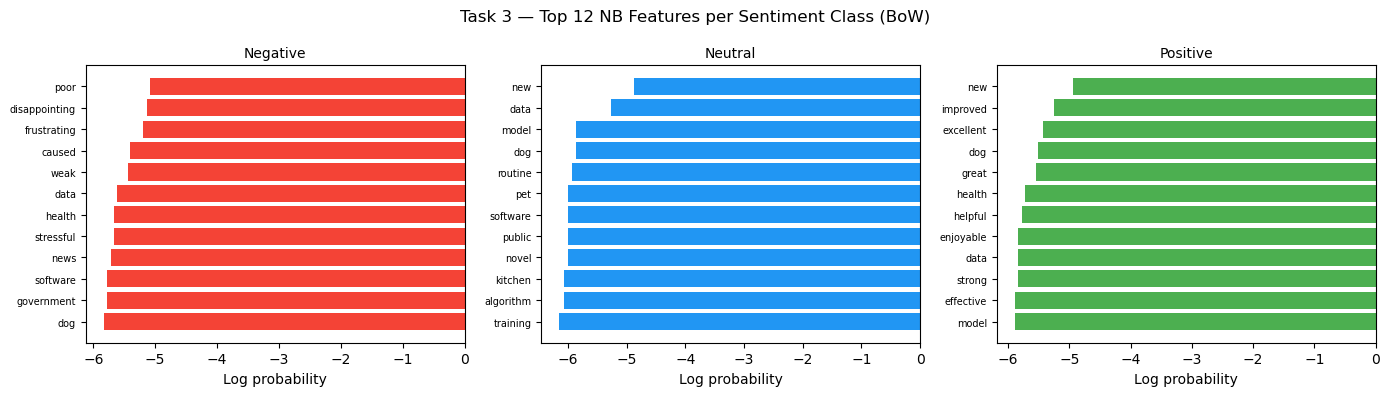

In [97]:
# Train NB on the full corpus to inspect which words drive each sentiment class
nb_full = MultinomialNB()
nb_full.fit(X_bow, y_sentiment)

feature_names = bow_vectorizer.get_feature_names_out()
sentiment_classes = nb_full.classes_

fig, axes = plt.subplots(1, len(sentiment_classes), figsize=(14, 4), sharey=False)
colors = {"Positive": "#4CAF50", "Negative": "#F44336", "Neutral": "#2196F3"}

for ax, cls in zip(axes, sentiment_classes):
    log_probs = nb_full.feature_log_prob_[list(sentiment_classes).index(cls)]
    top_idx = np.argsort(log_probs)[-12:]
    ax.barh(feature_names[top_idx], log_probs[top_idx],
            color=colors.get(cls, "steelblue"))
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel("Log probability")
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Task 3 — Top 12 NB Features per Sentiment Class (BoW)", fontsize=12)
plt.tight_layout()
plt.show()

In [98]:
pd.DataFrame(tasks).sort_values("accuracy", ascending=False).reset_index(drop=True)

,title,accuracy
0,Task 1 — Category Classification | LR on BoW,0.805
1,Task 4 — Sentiment Classification | RF on BoW,0.789
2,Task 1 — Category Classification | LR on TF-IDF,0.773
3,Task 4 — Sentiment Classification | RF on TF-IDF,0.773
4,Task 4 — Category Classification | RF on TF-IDF,0.742
5,Task 4 — Category Classification | RF on BoW,0.734
6,Task 3 — Sentiment Classification | NB on TF-IDF,0.727
7,Task 3 — Sentiment Classification | NB on Bina...,0.727
8,Task 3 — Sentiment Classification | NB on BoW,0.703
9,Task 2 — Sentiment Classification | kNN (cosin...,0.625


NB Description: 

Naive Bayes trains using a probability model to determine the likelyhood of each word appearing given each sentiment. Aftewards, Naive Bayes theorem is used to pick the most likely class for new documents.

NB Results Explanation: 

Since Naive Bayes learns from the data (as opposed to kNN using distance), TF-IDF and Binary both outperformed the best of BoW. This is since TF-IDF lessense the weight of uninformative words like "the" that are in all three sentiment classes while giving more weight to distinctive sentiment terms. 

BoW is the weakest with Naive Bayes since Neutral is the hardest class across all methods to classify accurtely. This is likely because neutral documents naturally don't include strong sentiment vocabulary. This makes it look similar to both positive and negative documents in the vector. 

NB is useful for interpretation of features since it can show which words are most dominant for classifying documents of each class. kNN can't do this since.

# Unsupervised Learning (K-Means & Hierarchical Clustering)

In [99]:
def dense_array(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

def plot_pca_projection(X, labels, title):
    X_dense = dense_array(X)
    points = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_dense)
    plot_df = pd.DataFrame({"x": points[:, 0], "y": points[:, 1], "label": labels})
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x="x", y="y", hue="label", s=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def run_kmeans_and_compare(X, label_column, title, k=5):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    clusters = km.fit_predict(X)
    comparison = pd.crosstab(pd.Series(clusters, name="cluster"), df[label_column])
    print(title)
    display(comparison)
    plot_pca_projection(X, clusters, title + " - PCA View")
    return clusters

k-means on TF-IDF compared with category


category_label,CS/Data Science,Food/Home/Pets,Health/Activity,Lit/Music/TV,News/Politics
cluster,,,,,
0,38,43,48,59,112
1,3,0,1,38,10
2,13,36,8,17,24
3,74,3,4,6,17
4,12,3,56,9,5


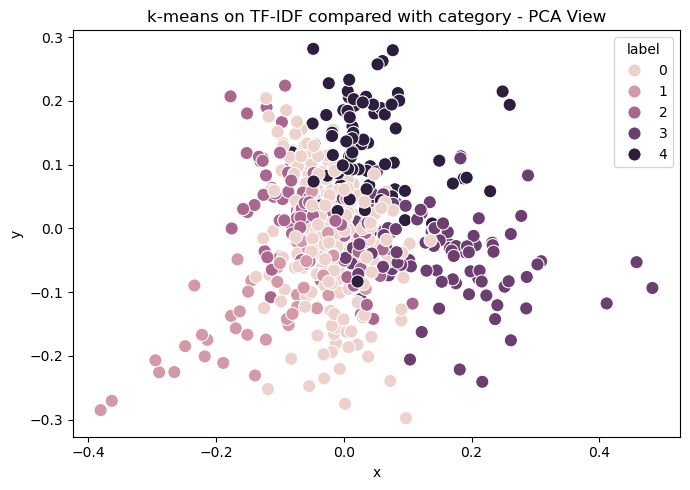

k-means on BoW compared with category


category_label,CS/Data Science,Food/Home/Pets,Health/Activity,Lit/Music/TV,News/Politics
cluster,,,,,
0,7,33,26,7,6
1,26,6,8,20,32
2,1,0,2,0,0
3,0,0,2,1,0
4,106,46,79,101,130


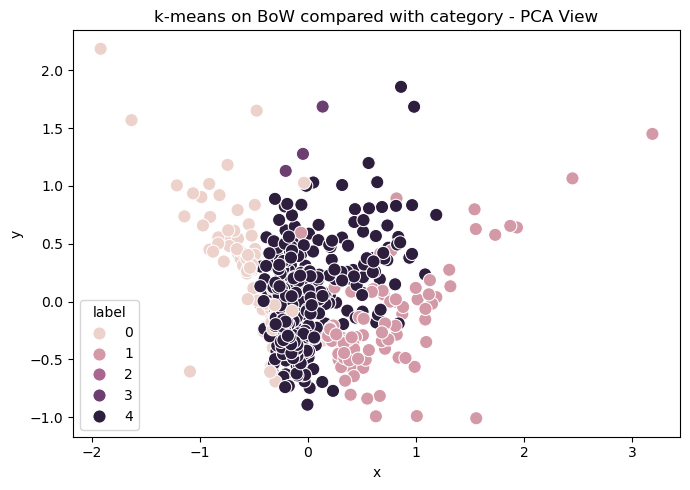

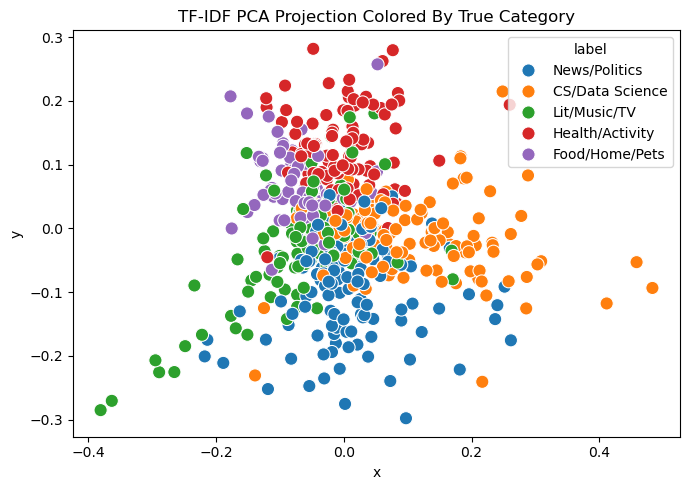

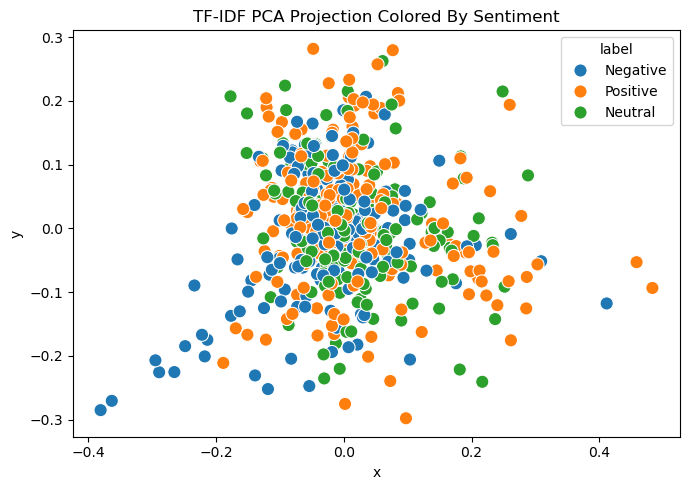

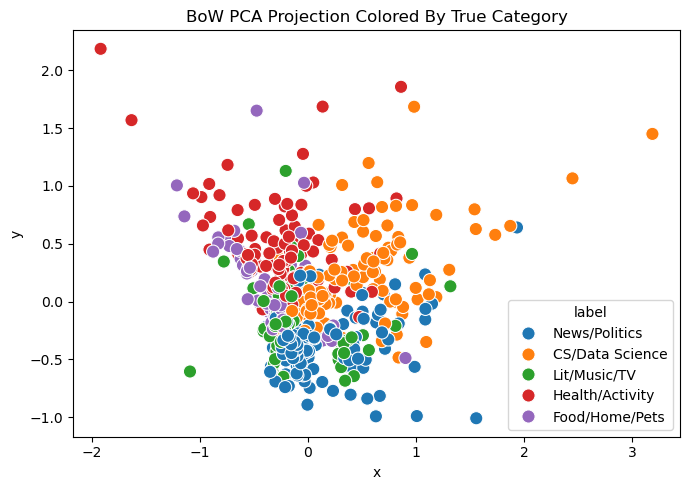

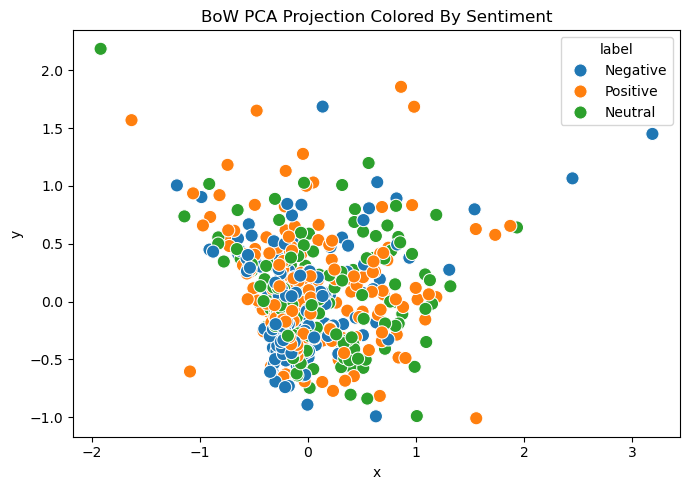

In [100]:
tfidf_clusters = run_kmeans_and_compare(X_tfidf, "category_label", "k-means on TF-IDF compared with category")
bow_clusters = run_kmeans_and_compare(X_bow, "category_label", "k-means on BoW compared with category")

plot_pca_projection(X_tfidf, df["category_label"], "TF-IDF PCA Projection Colored By True Category")
plot_pca_projection(X_tfidf, df["sentiment"], "TF-IDF PCA Projection Colored By Sentiment")

plot_pca_projection(X_bow, df["category_label"], "BoW PCA Projection Colored By True Category")
plot_pca_projection(X_bow, df["sentiment"], "BoW PCA Projection Colored By Sentiment")

## Unsupervised analysis

The principal component analysis performed on the dataset using k-means allos us to see the difference in variance between documents. 

### Question 1:How strong of clusters are formed by K-Means clustering?
We are first able to see that BoW is not very useful for drawing conclusions due to filler words not being normalized, so we can take a look at the TF-IDF chart. Doing so for K-means clusters by category results in several very strong centroids for certain categories. 
Cluster 1 is a small but very precise cluster centered around 38 Lit/Music/TV documents, cluster 3 has a strong relatioship to CS/DS with 74/104 documents, and cluster 4 is strongly centered around 56 instances of Health/Activity with minimal noise. However, we also see that cluster 0 has a wide spread of categories witht he most present being News/Politics, indicating it was difficult to differentiate between News/Politics and other categories likely due to terms having overlap for similar topics within many other categories that are used to describe things in politics. We are similarly also able to tell that in cluster 2 it has a focus on Food/Home/Pets but lacks the ability to have strong clustering similar to cluster 0, thus lacking weight when TF-IDF is applied to it. 

### Question 2: What strong connections exist between categories and sentiment in K-means clustering?
From the TF-IDF PCA Projection Colored By Sentiment we can see that there is very large blob in the center containing a large variety of all 3 sentiments. This tells us that the sentiment words used are similar to those across all docs. We also can see a long tail of negative sentiments which all come from the same grouping of documents about Lit/Music/TV. The sentiments may appear close in distance due to the fact that they were student made and contain words from a shared vocabulary list creating a lack of spread.

### Question 3: How polarized in sentiment is the News/Politics categories?
The news/politics category has an almost even distribution of sentiment scores, meaning that there is large polarization with many people feeling neutral, negative and positive about most likely similar topics and it can thus be inferred that there is a large spread of opinions in political documents across issues, but they may be similar if we look at specific topics.

### Question 4: Are the Food/Home/Pets related to the Health/Activity Categories, is there shared sentiment? Why are the more or less likely to be related?
The Food/Home/Pets catergory has 54 documents that are shared with Health/Acitivity. They have a lot of distance overlap with each other on the PCA TF-IDF Visuals indicating that they might have high similarities for words that are related to both but not necessarily specific to either, like food items being related to health or pets being related to activities.


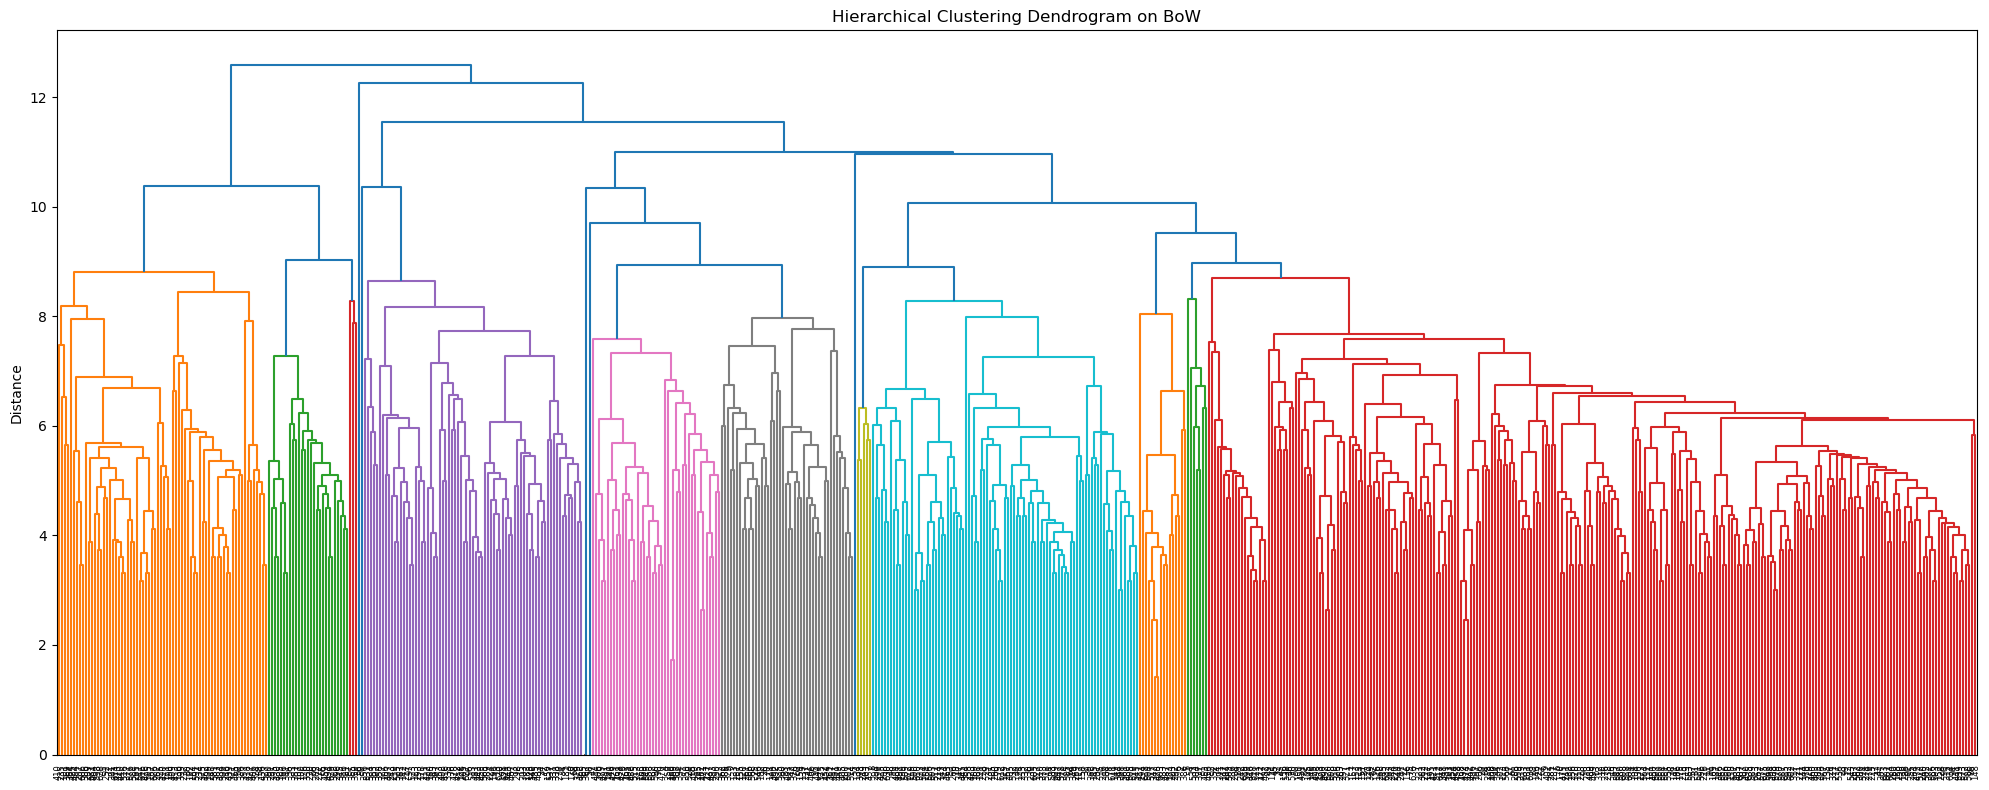

In [101]:
linked = linkage(dense_array(X_bow), method = "ward")

plt.figure(figsize=(20,8))
dendrogram(linked,
            #labels=[f"{i}:{cat}" for i, cat in enumerate(df['category_label'])],
              leaf_rotation=90,
                leaf_font_size=6
                )
plt.title("Hierarchical Clustering Dendrogram on BoW")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

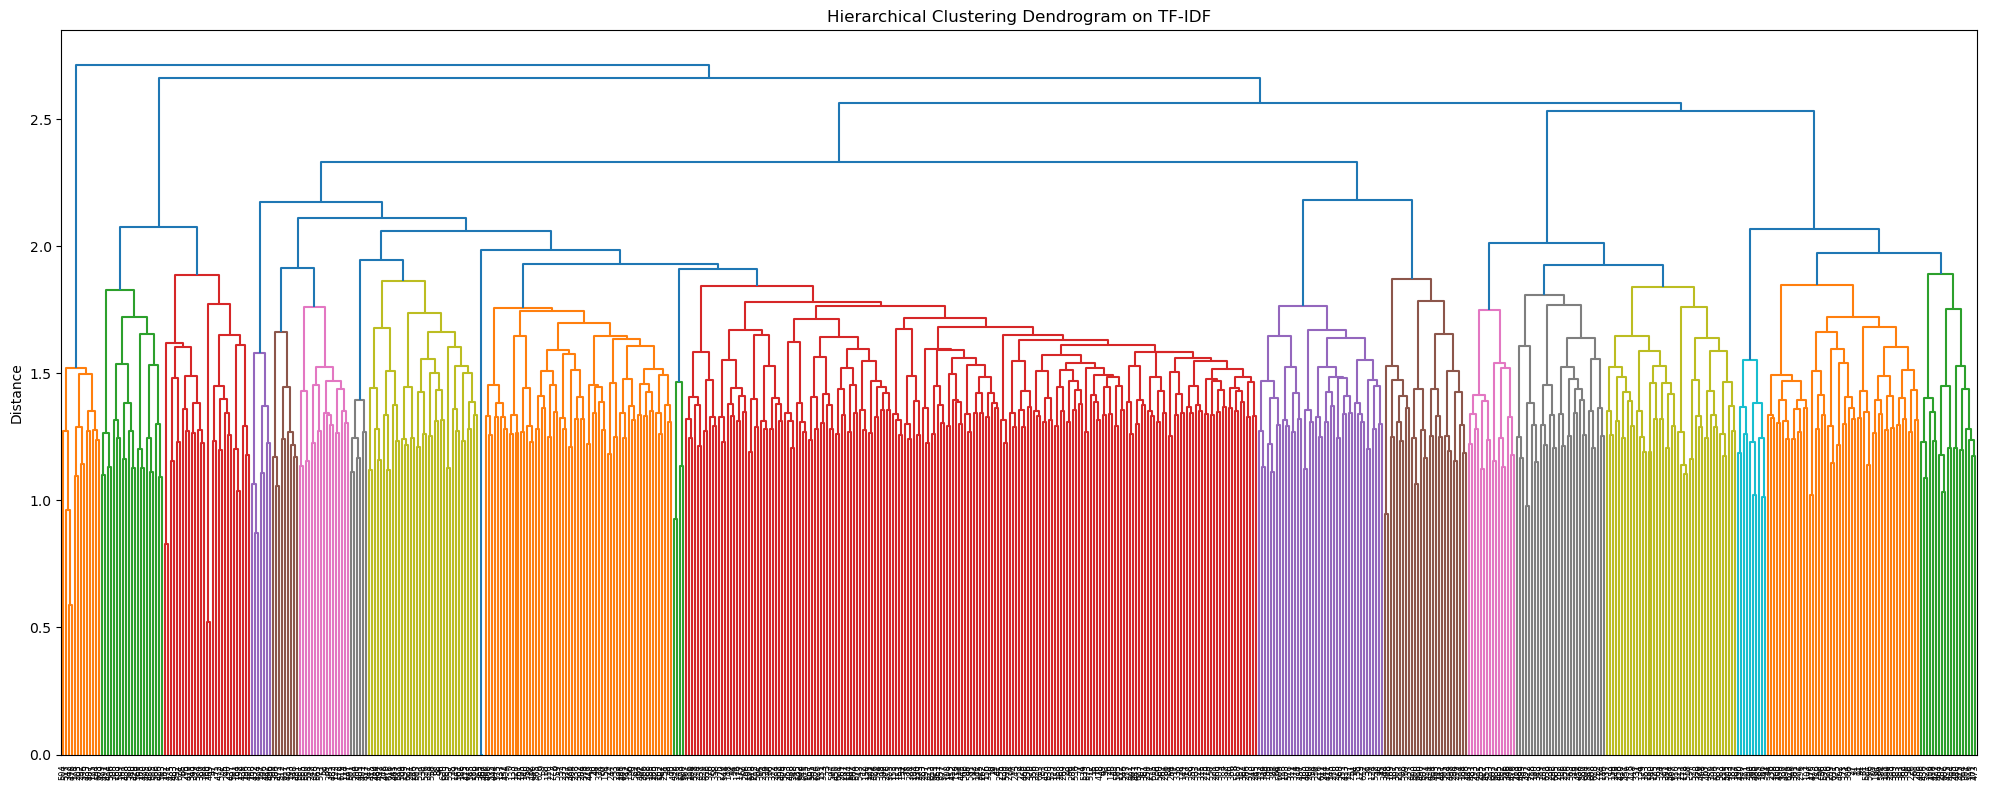

In [102]:
linked = linkage(dense_array(X_tfidf), method="ward")
plt.figure(figsize=(20, 8))
dendrogram(linked,
            # labels=[f"{i}:{cat}" for i, cat in enumerate(df['category_label'])],
              leaf_rotation=90,
                leaf_font_size=6 #, truncate_move = 'level', p=5
                )
plt.title("Hierarchical Clustering Dendrogram on TF-IDF")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [103]:
agg = AgglomerativeClustering(n_clusters=5)
df["hier_cluster"] = agg.fit_predict(dense_array(X_bow))
print("Agglomerative Clustering on BoW")
pd.crosstab(df["hier_cluster"], df["category_label"])

Agglomerative Clustering on BoW


category_label,CS/Data Science,Food/Home/Pets,Health/Activity,Lit/Music/TV,News/Politics
hier_cluster,,,,,
0,71,76,64,110,53
1,55,4,6,11,24
2,0,0,0,1,0
3,12,3,46,4,9
4,2,2,1,3,82


In [104]:
agg = AgglomerativeClustering(n_clusters=5)
df["hier_cluster"] = agg.fit_predict(dense_array(X_tfidf))
print("Agglomerative Clustering on TF-IDF")
pd.crosstab(df["hier_cluster"], df["category_label"])

Agglomerative Clustering on TF-IDF


category_label,CS/Data Science,Food/Home/Pets,Health/Activity,Lit/Music/TV,News/Politics
hier_cluster,,,,,
0,72,78,51,102,103
1,55,1,4,7,13
2,1,0,0,0,49
3,1,0,0,10,2
4,11,6,62,10,1


### Question 5: How closely related are documents between categories? What does BoW and TF-IDF tell us about these?

The raw bag-of-words approach contains the catch-all cluster of cluster 1, outliers in clusters 0 and 2 contained unique vocabulary that didn't directly relate to any other cluster, mostly in Food and Health in cluster 0 indicating words not seen elsewhere in the set. Cluster 3 contained mixed activity mostly containing health/activity, but also contained CS/DS and News documents, while cluster 4 contained a strong tendency to contain news/politics as part of CS/Data science. 

Since TF-IDF normalizes the data and can better represent how clusters form as a result, we can more clearly see how strictly categorized documents are. Clusters 1, 2, 3, and 4 all group documents based purely on subject matter. 
Cluster 1 had highly clustered CS/Data science information with 55/80 documents in cluster, with some extraneous relation to 13 News/Politics documents. 
Cluster 2 contained News/Politics documents nearly exclusively with 49/50 documents, with one CS/Data science document also included in the cluster, which also ties back into the two categories being closely related due to News/Politics showing up often in cluster 1's highly CS/DS focused classification. 
Cluster 3 was a small cluster, only a few Literature, Music, and TV documents are closely related. 
Cluster 4 has mostly Health/Activity with 62 documents, with some pull (5-10 documents)to every other category, indicating that there is a small amount of overlap between all categories.

Notably, cluster 0 was a large mixed group made up of all previous categories and the Food/Home/Pets cluster which failed to make its own and instead was fully swallowed by the containing cluster. This indicates that Food/Home/Pets has a very weak cluster, and that its vocabulary list may not contain strong unique words or have significant overlap with other categories. This may also apply to Literature, Music, and TV as well since it may have significant overlap with multiple other documents, causing documents without strong unique words like names or titles to be difficult to cluster.

These findings are reflected within the hierarchical clustering dendogram, as we are able to see that several categories have smaller, disconnected clusters and thus have significant overlap with different categories than themselves at high cluster levels, indicating a weak cluster.

### Question 6: How closely correlated Food/Home/pets and Literature/Music/TV? Is their similarity dependent caused by similar attributes?
The Food/Home/Pets and Literature/Music/TV have some overlap, however by examining the relationship by the TF-IDF PCA visual, there isn't enough evidence to suggest that they are correlated by clusters, but instead by attributes. Some attributes that could overlap could be due to terms associated to either category being in the same sentence, or overlapping descriptive words being used and assigned to both categories like shows or movies that would relate to food/home/pets like paw patrol or a cooking/home improvement show.

# VADER and Sentence-BERT

## VADER

In [ ]:
analyzer = SentimentIntensityAnalyzer()

# Code below from Stack Overflow: https://stackoverflow.com/questions/19364571/plotting-vader-sentiment-analysis-results-in-python
df['compound'] = [analyzer.polarity_scores(x)['compound'] for x in df['text']]
df['neg'] = [analyzer.polarity_scores(x)['neg'] for x in df['text']]
df['neu'] = [analyzer.polarity_scores(x)['neu'] for x in df['text']]
df['pos'] = [analyzer.polarity_scores(x)['pos'] for x in df['text']]
df['rating'] = df['compound'].apply(lambda c: 'Positive' if c >= 0.05 else ('Negative' if c <= -0.05 else 'Neutral'))

X_vader = df[['neg', 'neu', 'pos', 'compound']]

### Supervised Learning - VADER

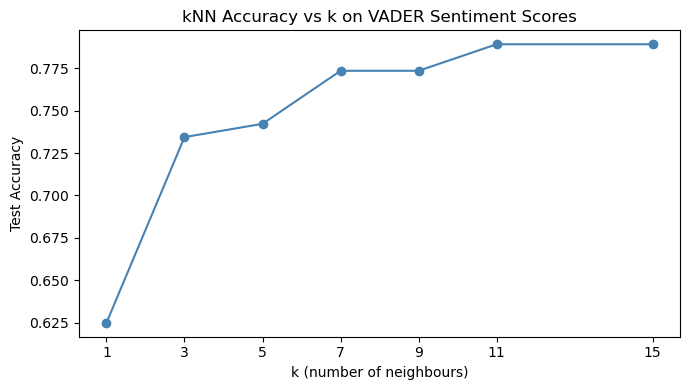

In [110]:
#finding the best k on vader sentiment scores
X_tr, X_te, y_tr, y_te = train_test_split(
    X_vader, y_sentiment, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sentiment
)

k_values = [1, 3, 5, 7, 9, 11, 15]
k_accs   = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_tr, y_tr)
    k_accs.append(accuracy_score(y_te, knn.predict(X_te)))

plt.figure(figsize=(7, 4))
plt.plot(k_values, k_accs, marker="o", color="steelblue")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Test Accuracy")
plt.title("kNN Accuracy vs k on VADER Sentiment Scores")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

LR on VADER Sentiment Scores
Accuracy: 0.781
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84        42
     Neutral       0.66      0.78      0.71        40
    Positive       0.89      0.72      0.80        46

    accuracy                           0.78       128
   macro avg       0.79      0.78      0.78       128
weighted avg       0.80      0.78      0.78       128



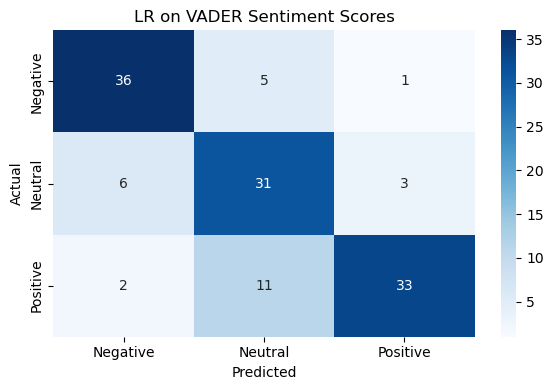

kNN (cosine) on VADER Sentiment Scores
Accuracy: 0.742
              precision    recall  f1-score   support

    Negative       0.77      0.88      0.82        42
     Neutral       0.60      0.65      0.63        40
    Positive       0.86      0.70      0.77        46

    accuracy                           0.74       128
   macro avg       0.75      0.74      0.74       128
weighted avg       0.75      0.74      0.74       128



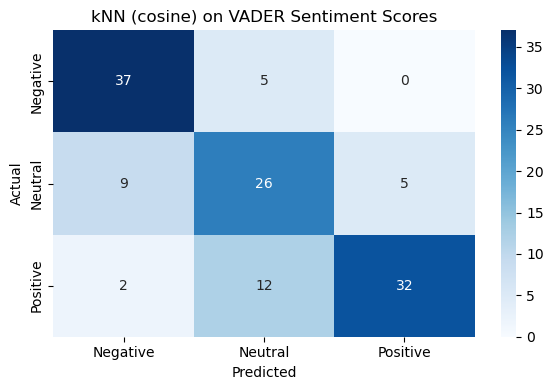

NB on VADER Sentiment Scores
Accuracy: 0.742
              precision    recall  f1-score   support

    Negative       0.80      0.83      0.81        42
     Neutral       0.71      0.50      0.59        40
    Positive       0.71      0.87      0.78        46

    accuracy                           0.74       128
   macro avg       0.74      0.73      0.73       128
weighted avg       0.74      0.74      0.73       128



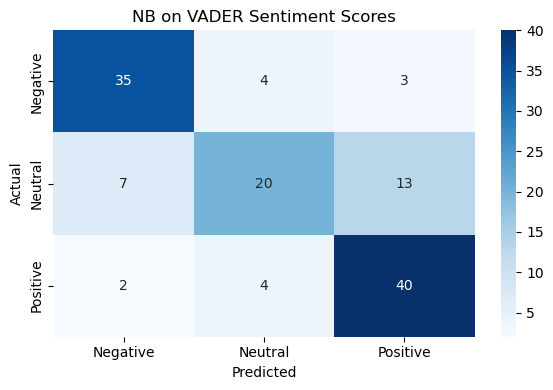

RF on VADER Sentiment Scores
Accuracy: 0.727
              precision    recall  f1-score   support

    Negative       0.74      0.83      0.79        42
     Neutral       0.64      0.68      0.66        40
    Positive       0.79      0.67      0.73        46

    accuracy                           0.73       128
   macro avg       0.73      0.73      0.72       128
weighted avg       0.73      0.73      0.73       128



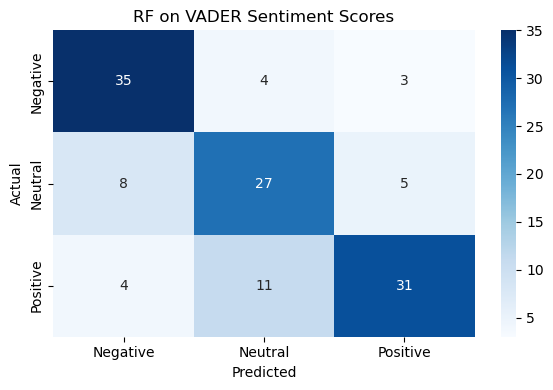

In [ ]:
tasks.append(evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_vader, y_sentiment,
    "LR on VADER Sentiment Scores"
))

tasks.append(evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    X_vader, y_sentiment,
    "kNN (cosine) on VADER Sentiment Scores"
))

scaler = MinMaxScaler()
X_vader_scaled = scaler.fit_transform(X_vader)
tasks.append(evaluate_classifier(
    MultinomialNB(),
    X_vader_scaled, y_sentiment,
    "NB on VADER Sentiment Scores"
))

tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_vader, y_sentiment,
    "RF on VADER Sentiment Scores"
))

#### Comparing Supervised Learning VADER with Phase 2

The first visual for Logisitic Regression demonstrated similar accuracy, precision, and recall for Bag of Words (BoW) and TF-IDF. Both BoW and TF-IDF achieved a difference of 1% and 3% respectively. TF-IDF produced higher Negative and Neutral precision, as well as higher Positive recall, thus indicating that TF-IDF is able to more accurately predict Negative and Neutral values, while it is also better at producing true Positive values. We also see similar results with BoW, however only negative precision and positive recall produced higher results than VADER. 

The second visual for K-Nearest-Neighbors demonstrates an increased rate of accuracy by VADER, with a 15.6% increase compared to Bag-of-Words(BoW). Additionally, VADER's number of neighbors accuracy was significantly higher than the use of TF-IDF, regardless of which K-value was being used. The difference in accuracy compared to TF-IDF and Binary Prescence was 12.7% and 11.7%. 

The third visual for Naive Bayes demonstrated very similar results for BoW, TF-IDF, and Binary Prescence. We see only a difference of 2-4% accuracy compared to VADER Sentiment Scores. Additionally we see that TF-IDF exceeds VADER's ability to recall positive scores by 6%, indicating that TF-IDF is better at producing true positive results than VADER.

Lastly, the fourth visual for VADER Random Forest produced weaker results than BoW and TF-IDF. Accuracy, precision, and recall were significantly weaker than either BoW or TF-IDF's sentiment analysis. As a result, VADER's Sentiment Analysis through a random forest supervised learning method were not as strong.

### Unsupervised Learning - VADER

k-means on VADER Sentiment Scores compared with sentiment


sentiment,Negative,Neutral,Positive
cluster,,,
0,70,19,5
1,12,71,67
2,5,29,146
3,32,78,12
4,92,1,0


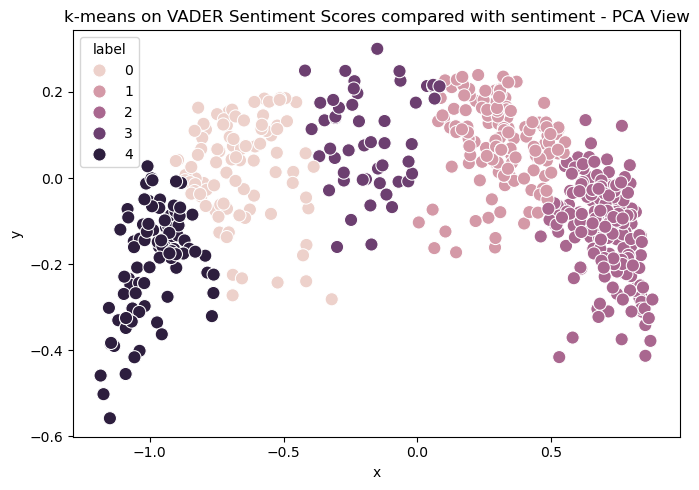

k-means on VADER Sentiment Scores compared with category


category_label,CS/Data Science,Food/Home/Pets,Health/Activity,Lit/Music/TV,News/Politics
cluster,,,,,
0,20,15,13,14,32
1,37,20,28,36,29
2,34,28,48,36,34
3,32,15,12,21,42
4,17,7,16,22,31


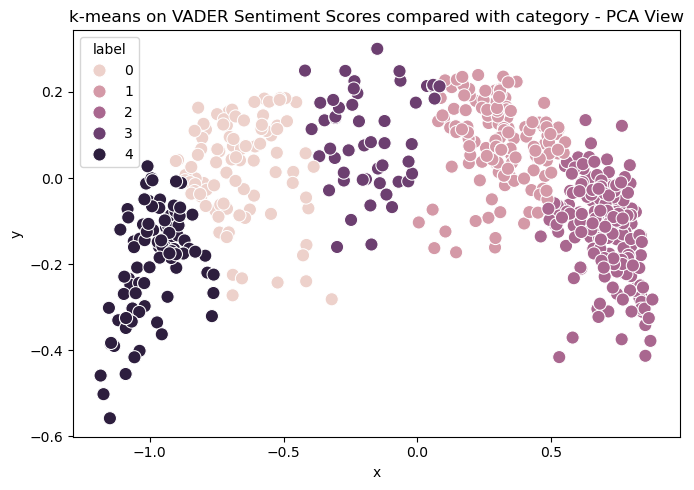

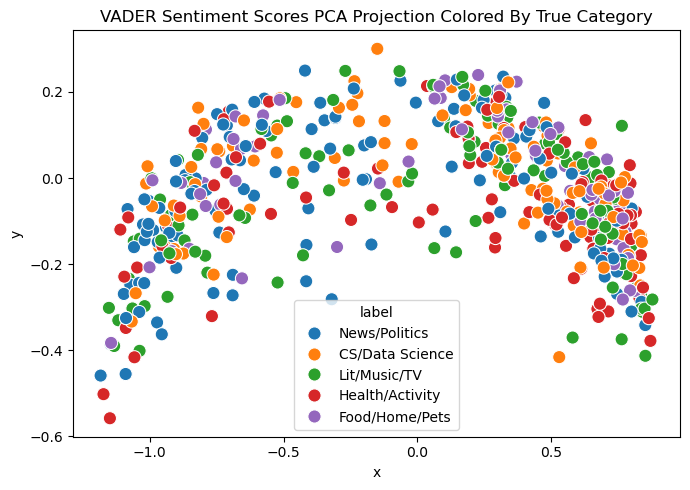

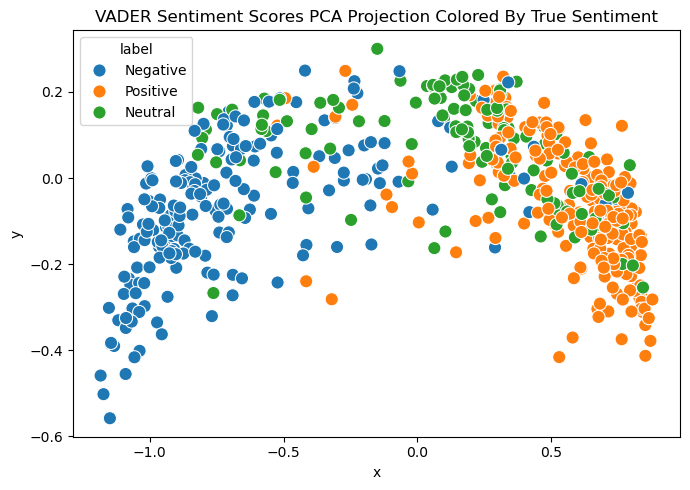

In [113]:
vader_clusters = run_kmeans_and_compare(X_vader, 
                                        "sentiment", 
                                        "k-means on VADER Sentiment Scores compared with sentiment")
vader_clusters = run_kmeans_and_compare(X_vader, 
                                        "category_label", 
                                        "k-means on VADER Sentiment Scores compared with category")

plot_pca_projection(X_vader, df["category_label"], "VADER Sentiment Scores PCA Projection Colored By True Category")
plot_pca_projection(X_vader, df["sentiment"], "VADER Sentiment Scores PCA Projection Colored By True Sentiment")

#### Comparing Unsupervised K-Means Learning VADER with Phase 3

VADER rates items on a scale of -1 to 1, thus the range of the PCA projection is within those boundaries.

Comparing it with the TF-IDF and BoW, VADER distributes the ranges of the items by sentiment instead of by category. We see that VADER fits a more uniform shape with sentiment, however by categorical it simply combines the values into one. 

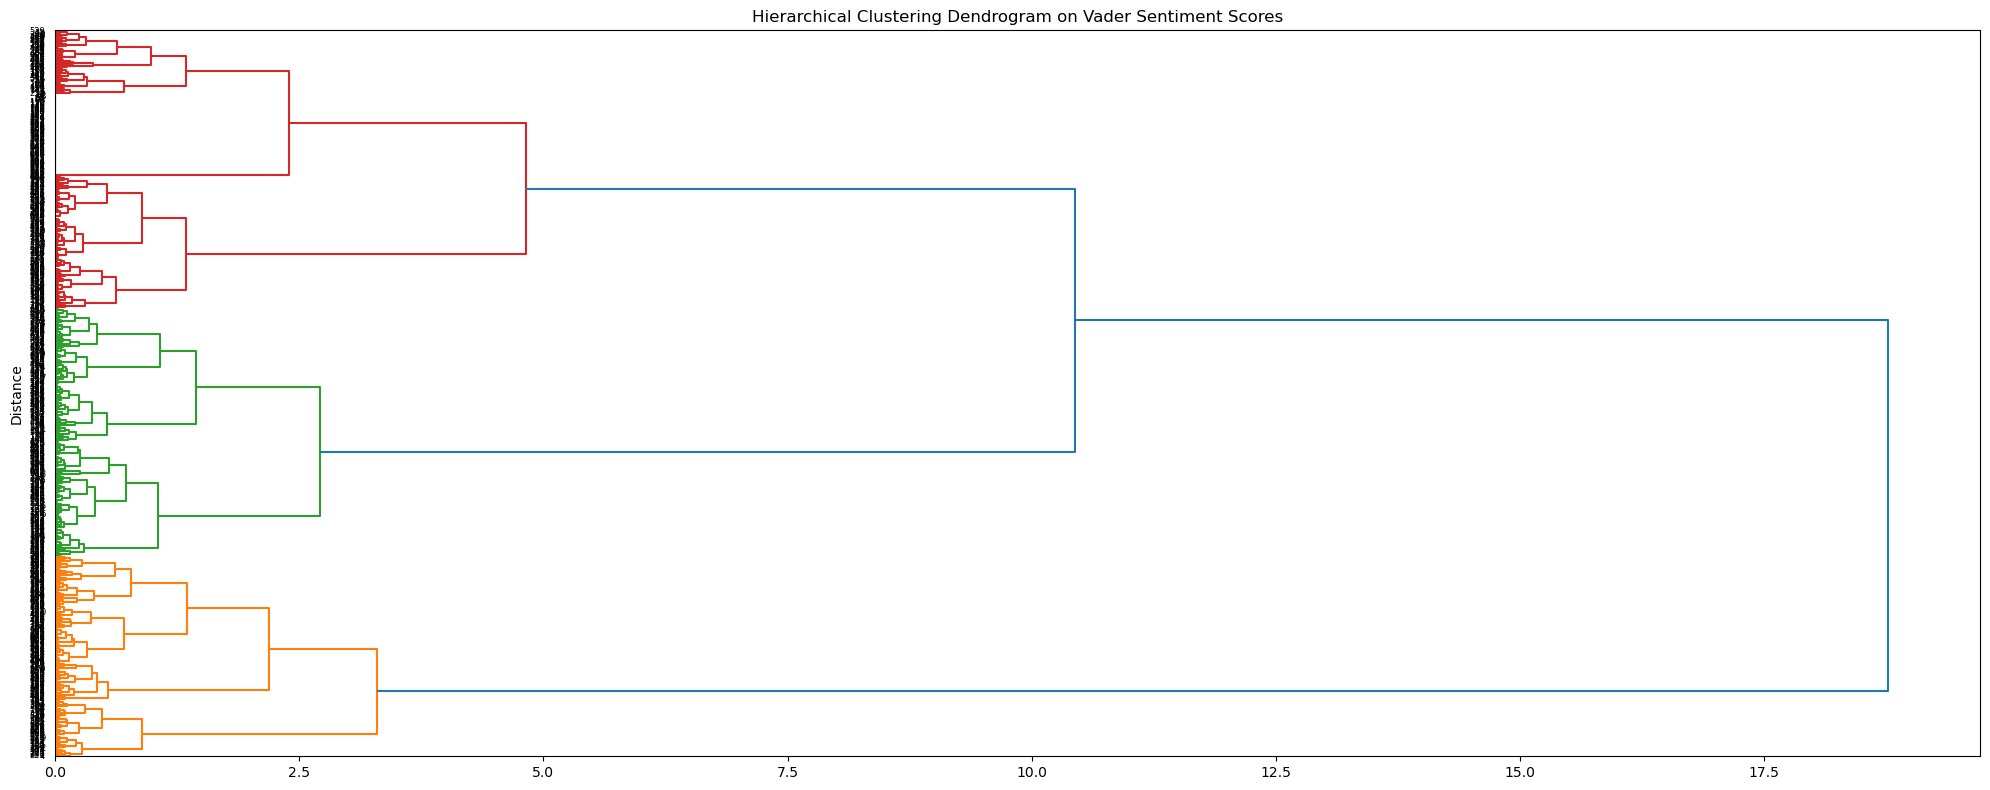

In [126]:
linked = linkage(dense_array(X_vader), method = "ward")

plt.figure(figsize=(20,8))
dendrogram(linked,
            orientation = 'right',
            leaf_font_size=6,
            color_threshold=0.5 * max(linked[:, 2])
          )
plt.title("Hierarchical Clustering Dendrogram on Vader Sentiment Scores")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

#### Comparing Unsupervised Hierarchical Learning VADER with Phase 3

Unlike the Hierarchical clustering for Bag of Words and TF-IDF, majority of the distances of the inital clusters were primarily grouped early on. We also set the color threshold to fit sentiment by 0.5, which set three primary clusters that represents the Negative, Neutral, and Positive sentiments. 

### Reduced Dataset - VADER

In [152]:
# Take a smaller subset of the data by dividing the number of documents by 5
num = df['doc_id'].size / 5

num = int(num)

#Compare VADER with a smaller dataset.

#Take a smaller subset of the data
random_dataset = df.sample(n=num, random_state=RANDOM_STATE)
X_vader_subset = random_dataset[['neg', 'neu', 'pos', 'compound']]
y_category_subset = random_dataset["category_label"]
y_sentiment_subset = random_dataset["sentiment"]

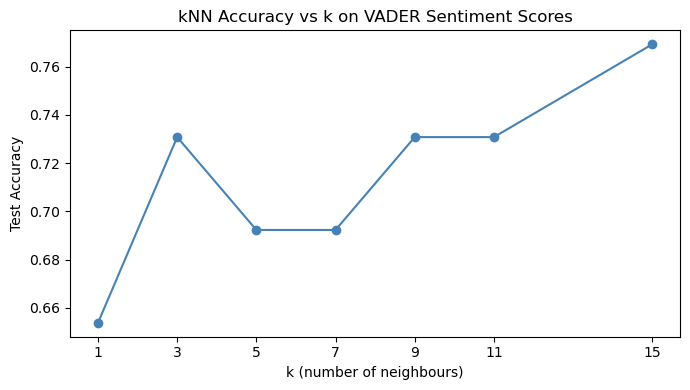

LR on VADER Sentiment Scores
Accuracy: 0.731
              precision    recall  f1-score   support

    Negative       0.78      0.78      0.78         9
     Neutral       0.67      0.50      0.57         8
    Positive       0.73      0.89      0.80         9

    accuracy                           0.73        26
   macro avg       0.72      0.72      0.72        26
weighted avg       0.73      0.73      0.72        26



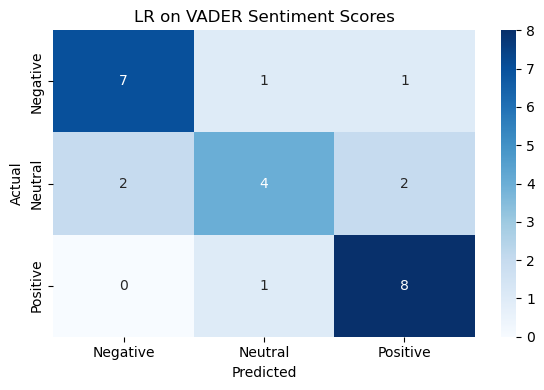

kNN (cosine) on VADER Sentiment Scores
Accuracy: 0.692
              precision    recall  f1-score   support

    Negative       0.70      0.78      0.74         9
     Neutral       0.50      0.50      0.50         8
    Positive       0.88      0.78      0.82         9

    accuracy                           0.69        26
   macro avg       0.69      0.69      0.69        26
weighted avg       0.70      0.69      0.69        26



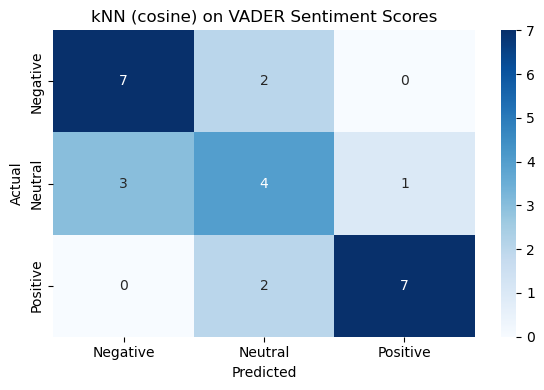

NB on VADER Sentiment Scores
Accuracy: 0.692
              precision    recall  f1-score   support

    Negative       0.70      0.78      0.74         9
     Neutral       0.60      0.38      0.46         8
    Positive       0.73      0.89      0.80         9

    accuracy                           0.69        26
   macro avg       0.68      0.68      0.67        26
weighted avg       0.68      0.69      0.67        26



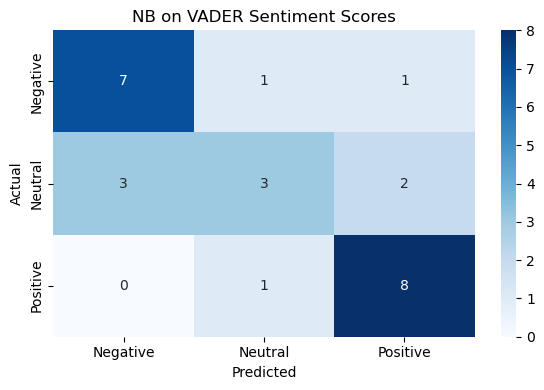

RF on VADER Sentiment Scores
Accuracy: 0.769
              precision    recall  f1-score   support

    Negative       0.80      0.89      0.84         9
     Neutral       0.62      0.62      0.62         8
    Positive       0.88      0.78      0.82         9

    accuracy                           0.77        26
   macro avg       0.77      0.76      0.76        26
weighted avg       0.77      0.77      0.77        26



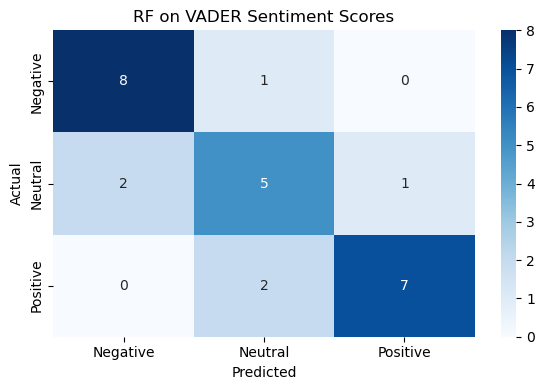

k-means on VADER Sentiment Scores compared with sentiment


sentiment,Negative,Neutral,Positive
cluster,,,
0,10,6,6
1,15,6,15
2,7,10,8
3,4,10,7
4,4,9,10


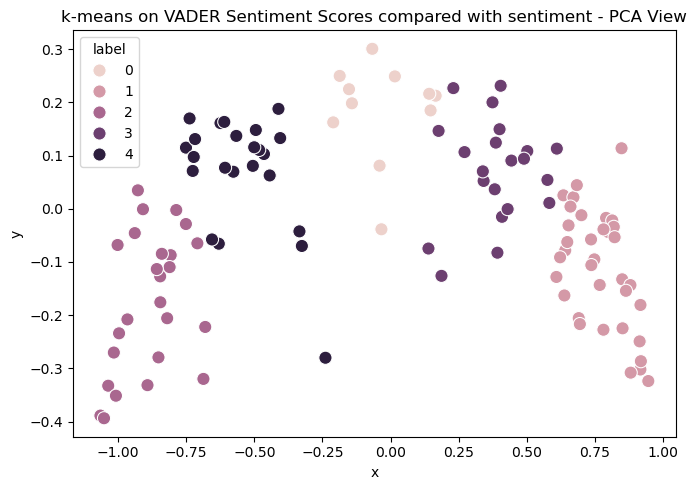

k-means on VADER Sentiment Scores compared with category


category_label,CS/Data Science,Food/Home/Pets,Health/Activity,Lit/Music/TV,News/Politics
cluster,,,,,
0,1,7,6,3,5
1,10,4,7,3,12
2,11,1,4,3,6
3,4,1,6,5,5
4,6,1,1,10,5


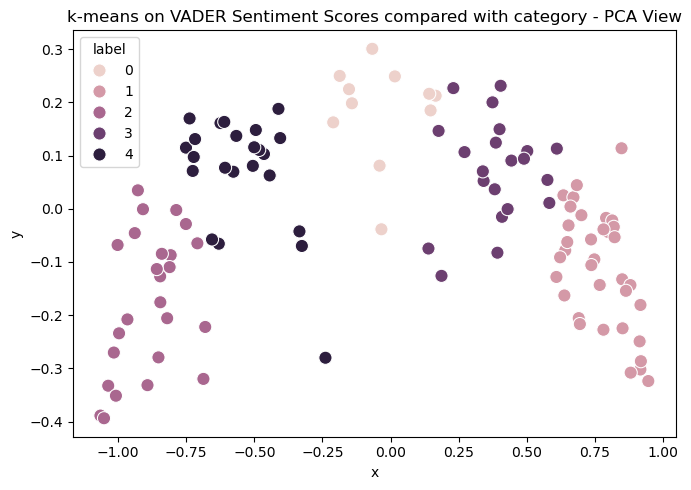

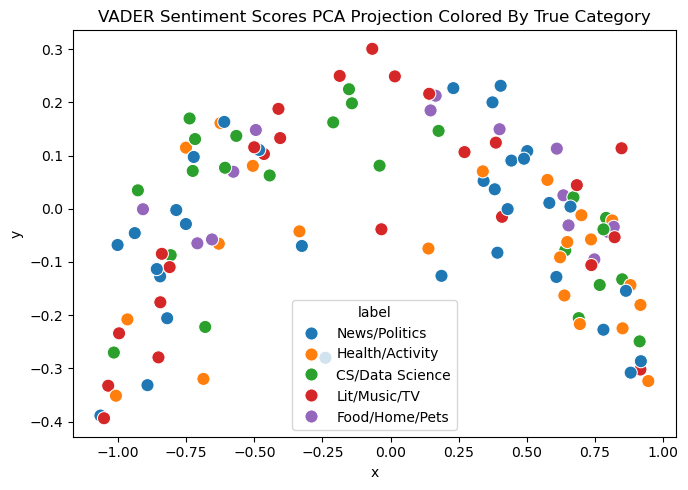

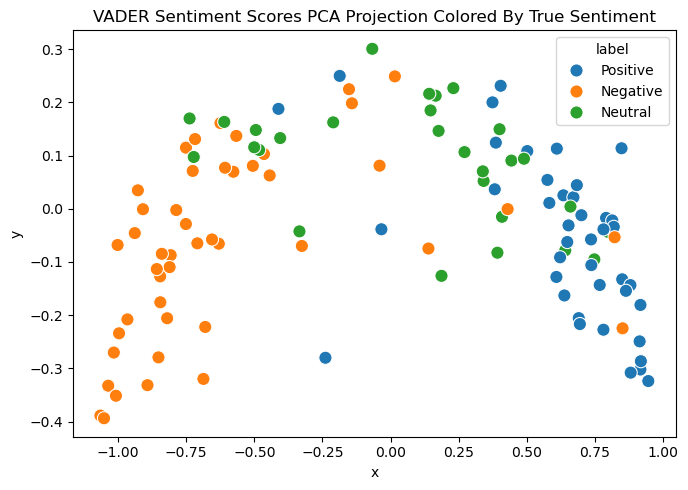

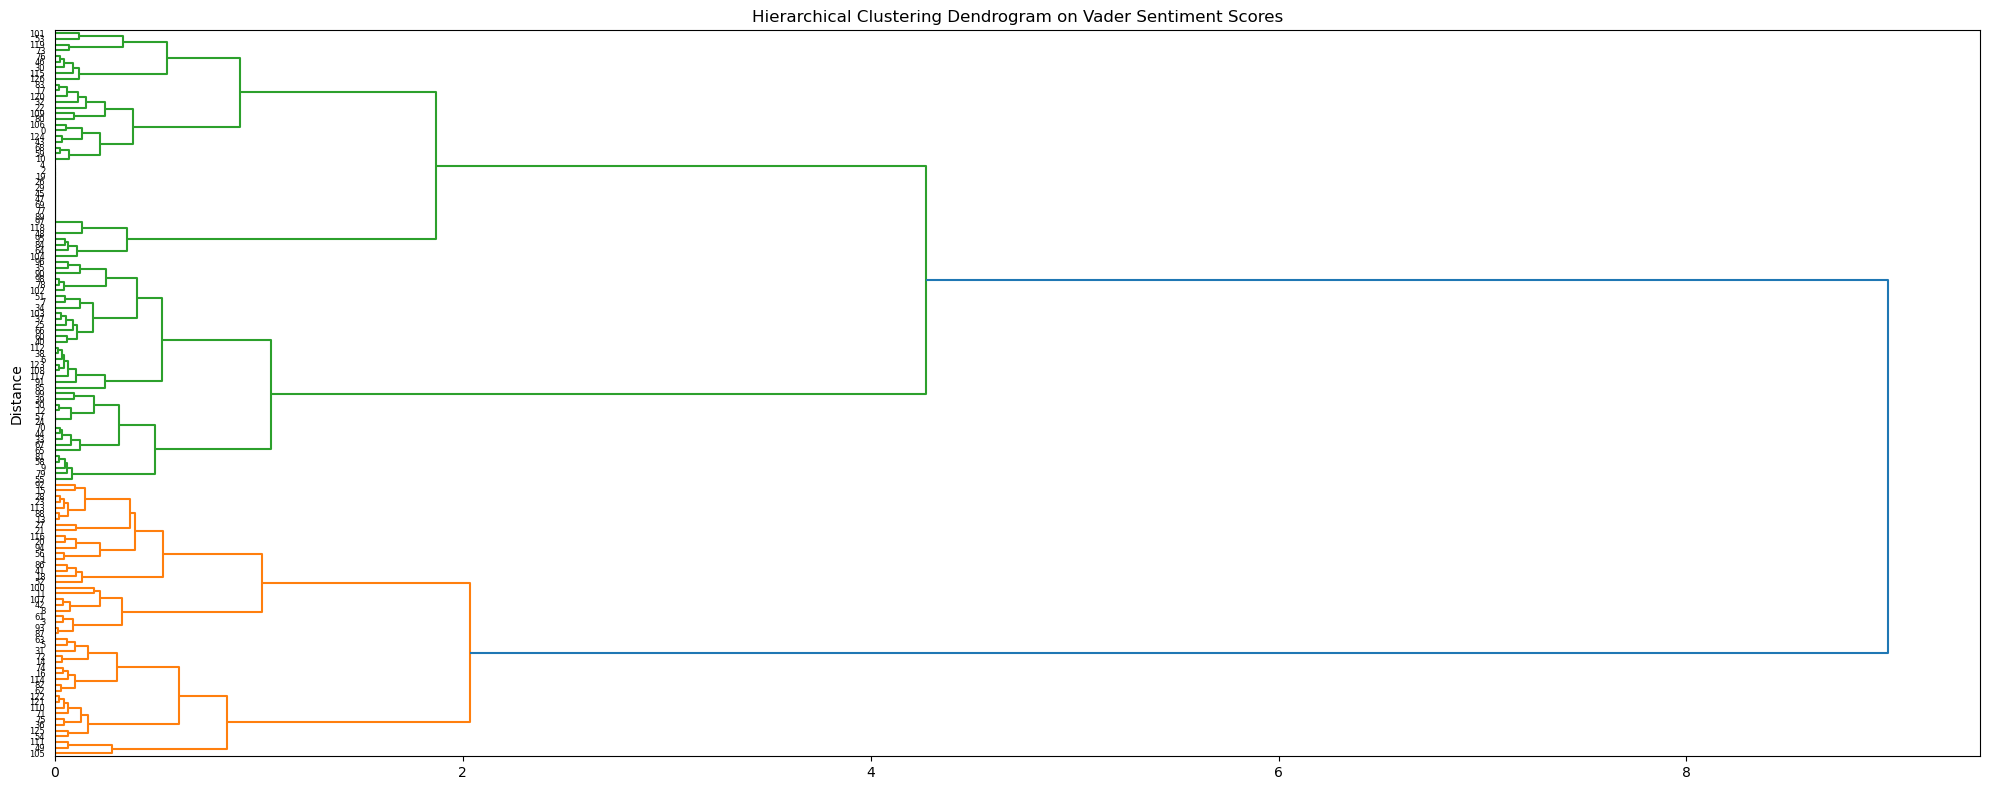

In [153]:
#finding the best k on vader sentiment scores
X_tr, X_te, y_tr, y_te = train_test_split(
    X_vader_subset, y_sentiment_subset, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sentiment_subset
)

k_values = [1, 3, 5, 7, 9, 11, 15]
k_accs   = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_tr, y_tr)
    k_accs.append(accuracy_score(y_te, knn.predict(X_te)))

plt.figure(figsize=(7, 4))
plt.plot(k_values, k_accs, marker="o", color="steelblue")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Test Accuracy")
plt.title("kNN Accuracy vs k on VADER Sentiment Scores")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

#Then run logistic regression, kNN, k-means, and hierarchical clustering on the VADER sentiment scores.
tasks.append(evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_vader_subset, y_sentiment_subset,
    "LR on VADER Sentiment Scores"
))

tasks.append(evaluate_classifier(
    KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    X_vader_subset, y_sentiment_subset,
    "kNN (cosine) on VADER Sentiment Scores"
))

scaler = MinMaxScaler()
X_vader_subset_scaled = scaler.fit_transform(X_vader_subset)
tasks.append(evaluate_classifier(
    MultinomialNB(),
    X_vader_subset_scaled, y_sentiment_subset,
    "NB on VADER Sentiment Scores"
))

tasks.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_vader_subset, y_sentiment_subset,
    "RF on VADER Sentiment Scores"
))

vader_clusters = run_kmeans_and_compare(X_vader_subset, 
                                        "sentiment", 
                                        "k-means on VADER Sentiment Scores compared with sentiment")
vader_clusters = run_kmeans_and_compare(X_vader_subset, 
                                        "category_label", 
                                        "k-means on VADER Sentiment Scores compared with category")

plot_pca_projection(X_vader_subset, y_category_subset, "VADER Sentiment Scores PCA Projection Colored By True Category")
plot_pca_projection(X_vader_subset, y_sentiment_subset, "VADER Sentiment Scores PCA Projection Colored By True Sentiment")

linked = linkage(dense_array(X_vader_subset), method = "ward")

plt.figure(figsize=(20,8))
dendrogram(linked,
            orientation = 'right',
            leaf_font_size=6,
            color_threshold=0.5 * max(linked[:, 2])
          )
plt.title("Hierarchical Clustering Dendrogram on Vader Sentiment Scores")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

#### Comparison with VADER using the reduced subset


## Sentence-BERT
### Supervised Learning - SBERT

In [ ]:
#SBERT sentence embedding function exmaple
def sentence_embedding(sentence):
    model = SentenceTransformer('all-MiniLM-L6-v2') #sets the model
    embedding = model.encode(sentence) #generates the embedding vector for the input sentence - and done!
    print(f"Sentence: {sentence}")
    print(f"Embedding Vector (first 5 values): {embedding[:5]}")
    return embedding

In [155]:
embedding_df = df['text'].apply(sentence_embedding).apply(pd.Series)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence: Trump's presidency has been tattered with scandal after scandal and corruption. Our weak and ineffective represenatives in goverment have abdicated their duty to impeach him.
Embedding Vector (first 5 values): [ 0.00448862 -0.00272557  0.11362351  0.0008426   0.01009105]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence: My machine learning course has been really enjoyable since we delve deep into the maths of it all including backpropagation. Even some of the simpler things like normilzation, svm, and tree methods have been cool to learn about.
Embedding Vector (first 5 values): [-0.02764987 -0.09274572  0.04083665 -0.02103051  0.00377826]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence: At her first book release, the author promised for the release of a triology, which made fans excited. 
Embedding Vector (first 5 values): [-0.03495899 -0.11145696 -0.00027945 -0.00259081 -0.08041437]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence: To maintian his vitality, the elderly man exercised everyday and did streches every morning. 
Embedding Vector (first 5 values): [ 0.06674814  0.11999492 -0.01228223  0.04382234 -0.11784334]


KeyboardInterrupt: 

### Unsupervised Learning - SBERT

### Reduced Dataset - SBERT

In [154]:
num
y_category_subset
y_sentiment_subset

86     Positive
353    Negative
570     Neutral
212    Negative
626     Neutral
         ...   
213     Neutral
425    Positive
244    Positive
248     Neutral
369     Neutral
Name: sentiment, Length: 127, dtype: str